# Predicting Online Purchase Behaviour from Website Engagement
>**DSCI 310, Group 2**
Authors: Aidan Aimy, Adrian Chan, Yujia Huang, Renata Lovette

This project investigates whether website engagement metrics can predict whether an online visitor will complete a purchase on an e-commerce website. Specifically, we will examine behavioural indicators such as the number of pages visited, time spent on different types of pages, and engagement metrics such as bounce rate and exit rate.

Using the **Online Shoppers Purchasing Intention Dataset**, we perform exploratory data analysis and build a classification model to determine whether browsing behaviour can predict whether a visitor will generate revenue for the website.

Understanding these relationships may help businesses better understand online consumer behaviour and optimize website design and marketing strategies.

# Introduction

E-commerce platforms collect large amounts of behavioural data about how users interact with websites. Metrics such as the number of pages visited, time spent browsing products, and bounce rates can provide insight into customer engagement and purchase intent. Understanding which behavioural signals are associated with successful purchases can help businesses improve their online shopping experience.

In this project, we analyze user session data from an e-commerce website to investigate whether engagement metrics can predict whether a visitor completes a purchase.

### Research Question

Can website engagement metrics (such as page visits, time spent on pages, and bounce rate) predict whether an online visitor will make a purchase?

### Dataset
The dataset used in this project is the **Online Shoppers Purchasing Intention Dataset** from the UCI Machine Learning Repository.

The dataset contains information about user browsing sessions on an e-commerce website. Each row represents a user session and includes both behavioural metrics and contextual information about the visit.

Key behavioural variables include:

- Administrative (number of administrative pages visited)
- Administrative_Duration (time spent on administrative pages)
- Informational (number of informational pages visited)
- Informational_Duration (time spent on informational pages)
- ProductRelated (number of product-related pages visited)
- ProductRelated_Duration (time spent on product-related pages)
- BounceRates (percentage of visitors who leave after viewing one page)
- ExitRates (percentage of exits from a page)
- PageValues (average value of a page before a purchase)
- SpecialDay (proximity to special shopping days)

The dataset also includes categorical variables such as month, operating system, browser type, region, traffic source, visitor type, and whether the session occurred on a weekend.

The target variable for this project is **Revenue**, which indicates whether a visitor completed a purchase during the session.

# Methods

In [3]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
In this section, we load the dataset and inspect its structure.

In [4]:
# load dataset
df = pd.read_csv('data/online_shoppers_data.csv')
print("Original shape:", df.shape)

Original shape: (12330, 18)


## Data Cleaning and Preparation
Before performing analysis, the dataset may require preprocessing steps such as:

- Checking for missing values
- Converting categorical variables to appropriate formats
- Preparing features for modeling

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

# Drop rows with missing values
df_cleaned = df.dropna()
print("Shape after dropping missing values:", df_cleaned.shape)

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()
print("Shape after dropping duplicates:", df_cleaned.shape)
#There is no missing values or duplicates in the dataset, so the shape remains unchanged.

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
Shape after dropping missing values: (12330, 18)
Shape after dropping duplicates: (12205, 18)

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                

In [6]:
# column names
print(df.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')


In [7]:
# Convert categorical data to numeric
import pandas as pd

# Convert VisitorType to numeric
visitor_map = {
    "Returning_Visitor": 2,
    "New_Visitor": 1,
    "Other": 0
}
df["VisitorType"] = df["VisitorType"].map(visitor_map)

# Convert Month to numeric
month_map = {
    "Jan":1, "Feb":2, "Mar":3, "Apr":4,
    "May":5, "June":6, "Jul":7, "Aug":8,
    "Sep":9, "Oct":10, "Nov":11, "Dec":12
}
df["Month"] = df["Month"].map(month_map)

# Check result

print("\nData types:")
print(df.dtypes)



Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                       bool
Revenue                       bool
dtype: object


In [8]:
# Check for impossible values

# Check that count variables are not negative
count_cols = [
    "Administrative",
    "Informational",
    "ProductRelated"
]

for col in count_cols:
    if (df[col] < 0).any():
        print(f"Warning: {col} contains negative values")

# Check that duration variables are not negative
duration_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

for col in duration_cols:
    if (df[col] < 0).any():
        print(f"Warning: {col} contains negative values")

# Check rate variables (should be between 0 and 1)
rate_cols = [
    "BounceRates",
    "ExitRates",
    "SpecialDay"
]

for col in rate_cols:
    if ((df[col] < 0) | (df[col] > 1)).any():
        print(f"Warning: {col} contains values outside [0,1]")

# PageValues should not be negative
if (df["PageValues"] < 0).any():
    print("Warning: PageValues contains negative values")

# Binary variables should only be 0 or 1
binary_cols = ["Weekend", "Revenue"]

for col in binary_cols:
    if not df[col].isin([0, 1]).all():
        print(f"Warning: {col} contains values other than 0 or 1")

print("Impossible value checks complete.")

Impossible value checks complete.


In [28]:
categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(sorted([x.item() for x in df[col].unique()]))



Unique values in Month:
[2, 3, 5, 6, 7, 8, 9, 10, 11, 12]

Unique values in OperatingSystems:
[1, 2, 3, 4, 5, 6, 7, 8]

Unique values in Browser:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Unique values in Region:
[1, 2, 3, 4, 5, 6, 7, 8, 9]

Unique values in TrafficType:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Unique values in VisitorType:
[0, 1, 2]


In [29]:
# Save cleaned data
df.to_csv('data/shopping_data_cleaned.csv', index=False)

print("\nCleaned dataset saved.")
print("Final shape:", df.shape)


Cleaned dataset saved.
Final shape: (12330, 18)


## Exploratory Data Analysis

Exploratory data analysis (EDA) helps us understand the distribution of variables and potential relationships between website engagement metrics and purchasing behaviour.

In this section, we will generate summary statistics and visualizations to explore different features of the dataset to understand the differences between sessions that resulted in purchases and those that did not. This section will focus on the following:

- Distribution of `Revenue`
- Distribution of page visits (`Administrative`, `Informational`, `ProductRelated`)
- Time spent on different types of pages (`Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`)
- `BounceRates` and `ExitRates`

In [30]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,False


### Revenue
> How many visits resulted in a purchase? Do returning or new customers make more purchases?

In [31]:
# count of page visits per page type
rev_count = df['Revenue'].value_counts()
rev_count

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [32]:
# revenue distribution among different customer types
rev_count_customer = df.groupby('VisitorType')['Revenue'].value_counts()
rev_count_customer

VisitorType  Revenue
0            False        69
             True         16
1            False      1272
             True        422
2            False      9081
             True       1470
Name: count, dtype: int64

### Comparing Page Visits
> Which pages have the most traction? Is there a difference in page visits that result in revenue and the ones that don't? Are there behavioural differences between returning and new customers?


In [33]:
# Page visits vs Revenue
page_columns = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                'ProductRelated', 'ProductRelated_Duration']
visits_vs_revenue = df.groupby('Revenue')[page_columns].mean()

visits_vs_revenue


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
Revenue,,,,,,
False,2.117732,73.740111,0.451833,30.236237,28.714642,1069.987809
True,3.393606,119.483244,0.786164,57.611427,48.210168,1876.209615


In [34]:
# Page visits vs customer type
visits_vs_customer = df.groupby('VisitorType')[page_columns].mean()

visits_vs_customer

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
VisitorType,,,,,,
0,1.470588,62.695588,0.176471,11.685490,12.470588,570.404862
1,2.551948,91.911315,0.333530,19.237472,18.054900,636.393354
2,2.283954,79.183639,0.533504,37.101992,34.082457,1289.421490


### Correlation Map of features

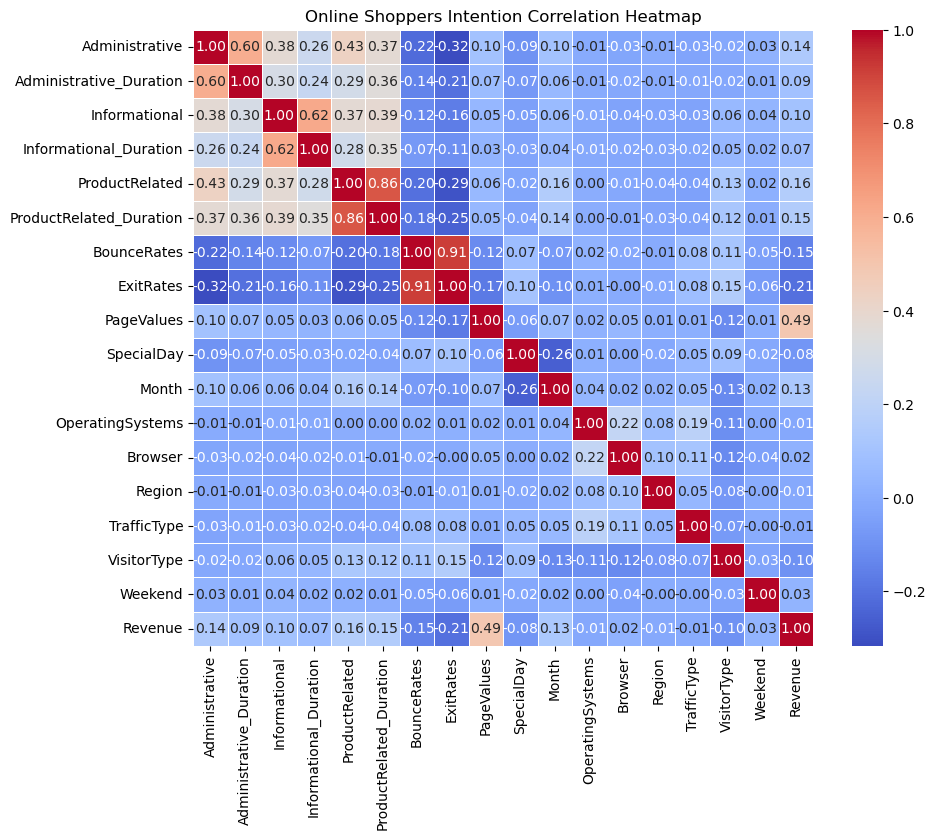

In [35]:
feature_correlation = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(feature_correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Online Shoppers Intention Correlation Heatmap")
plt.show()

## Classification Model

Because the target variable **Revenue** indicates whether a purchase occurred (True or False), this problem is formulated as a **binary classification task**.

We will train a classification model using website engagement metrics to predict whether a visitor completes a purchase.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Model Evaluation

To evaluate the performance of the classification model, we will use metrics such as:

- Accuracy
- Confusion matrix

These metrics will help assess how well the model predicts purchasing behaviour.

# Discussion

In this project, we investigated whether website engagement metrics can predict whether an online visitor completes a purchase.

We explored patterns in browsing behaviour and used a classification model to determine whether behavioural indicators such as page visits, browsing duration, and bounce rates could be used to predict purchasing outcomes.

The results of this analysis may help provide insight into how user engagement relates to purchase intent in e-commerce environments.

Future work could explore more advanced machine learning models or incorporate additional behavioural or demographic variables to improve predictive performance.

## References
Carmona, C. J., et al. “Web Usage Mining to Improve the Design of an E-commerce Website: OrOliveSur.com.” Expert Systems With Applications, vol. 39, no. 12, Apr. 2012, pp. 11243–49, doi:10.1016/j.eswa.2012.03.046.

M. A. Awad and I. Khalil, "Prediction of User's Web-Browsing Behavior: Application of Markov Model," in IEEE Transactions on Systems, Man, and Cybernetics, Part B (Cybernetics), vol. 42, no. 4, pp. 1131-1142, Aug. 2012, doi: 10.1109/TSMCB.2012.2187441.

Sakar, Cemal Okan et al. “Real-time prediction of online shoppers’ purchasing intention using multilayer perceptron and LSTM recurrent neural networks.” Neural Computing and Applications 31 (2018): 6893 - 6908.

Van Den Poel, Dirk, and Wouter Buckinx. “Predicting Online-purchasing Behaviour.” European Journal of Operational Research, vol. 166, no. 2, July 2004, pp. 557–75, doi:10.1016/j.ejor.2004.04.022.